In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


train = pd.read_csv('data/train.csv')
stores = pd.read_csv('data/stores.csv')
transactions = pd.read_csv('data/transactions.csv')
holidays = pd.read_csv('data/holidays_events.csv')
oil = pd.read_csv('data/oil.csv')

print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Transactions shape:", transactions.shape)
print(" Holidays shape:", holidays.shape)
print("Oil shape:", oil.shape)

Train shape: (3000888, 6)
Stores shape: (54, 5)
Transactions shape: (83488, 3)
 Holidays shape: (350, 6)
Oil shape: (1218, 2)


In [4]:

print("=" * 50)
print("TRAIN DATA:")
print("=" * 50)
print(train.head())

print("\n" + "=" * 50)
print("STORES DATA:")
print("=" * 50)
print(stores.head())

print("\n" + "=" * 50)

print("TRANSACTIONS DATA:")
print("=" * 50)
print(transactions.head())

print("\n" + "=" * 50)
print("HOLIDAYS DATA:")
print("=" * 50)
print(holidays.head())

print("\n" + "=" * 50)
print("OIL DATA:")
print("=" * 50)
print(oil.head())

TRAIN DATA:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

STORES DATA:
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

TRANSACTIONS DATA:
         date  store_nbr  transactions
0  2013-01-01         25           770
1  2013-01-02          1          2111
2  2013-01-02          2   

In [5]:
print("TRAIN - Missing Values:")
print(train.isnull().sum())
print("\nTrain date range:")
print("Start:", train['date'].min())
print("End:  ", train['date'].max())

print("\n" + "="*40)
print("OIL - Missing Values:")
print(oil.isnull().sum())

print("\n" + "="*40)
print("Train Columns Info:")
print(train.dtypes)

TRAIN - Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Train date range:
Start: 2013-01-01
End:   2017-08-15

OIL - Missing Values:
date           0
dcoilwtico    43
dtype: int64

Train Columns Info:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object


In [7]:
train['date'] = pd.to_datetime(train['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
oil['date'] = pd.to_datetime(oil['date'])

oil['dcoilwtico'] = oil['dcoilwtico'].fillna(method='ffill')

print("Date types fixed:")
print("Train date type:", train['date'].dtype)
print("Oil date type:", oil['date'].dtype)

print("\nOil missing values after fix:")
print(oil['dcoilwtico'].isnull().sum(), "missing values remaining")

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['day_of_week'] = train['date'].dt.dayofweek

print("\nNew columns added:")
print(train.columns.tolist())

C:\Users\scb\AppData\Local\Temp\ipykernel_23388\2375773805.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  oil['dcoilwtico'] = oil['dcoilwtico'].fillna(method='ffill')


Date types fixed:
Train date type: datetime64[ns]
Oil date type: datetime64[ns]

Oil missing values after fix:
1 missing values remaining

New columns added:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week']


In [8]:
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

print("Oil missing values:", oil['dcoilwtico'].isnull().sum())
print("Should be: 0")

Oil missing values: 0
Should be: 0


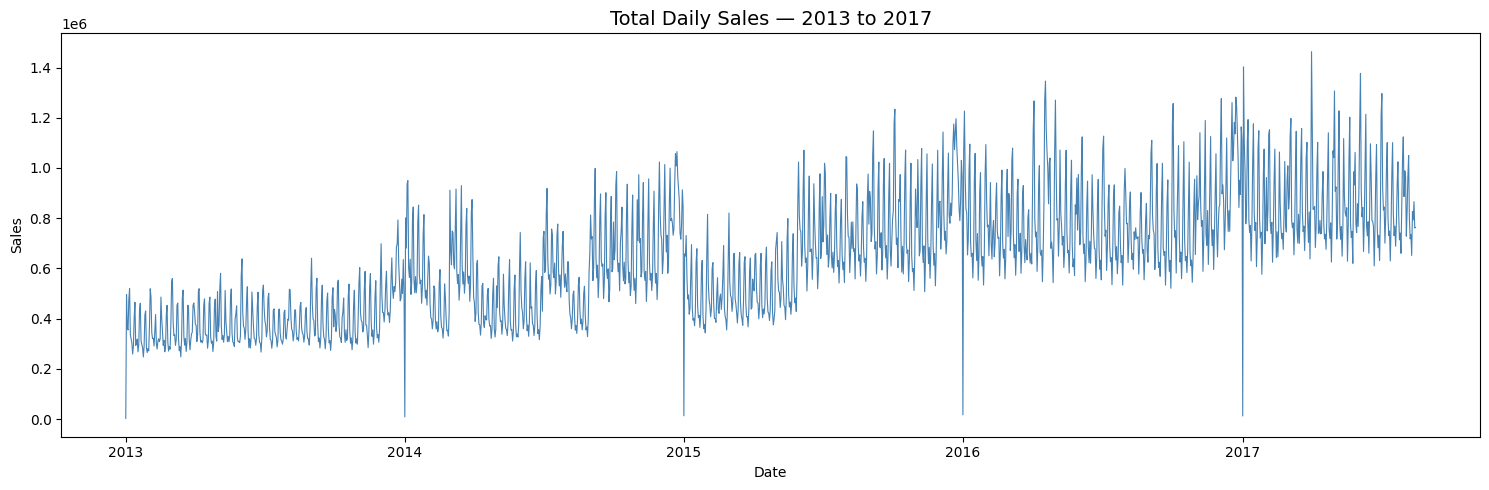

In [ ]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Sales — 2013 to 2017', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

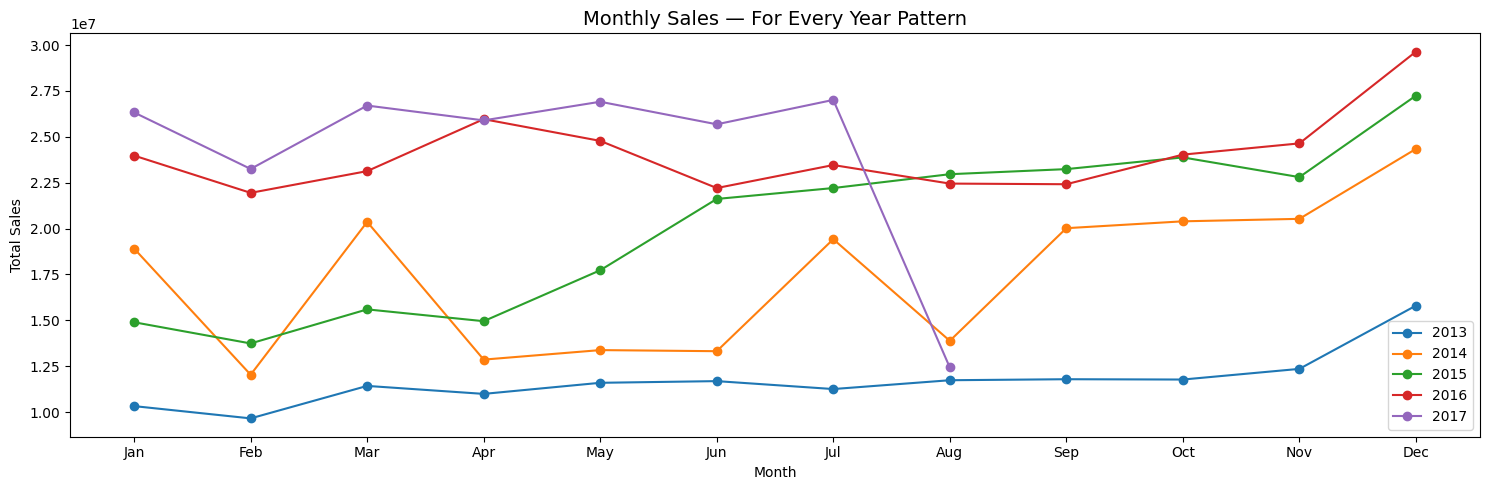

In [10]:

monthly_sales = train.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month'], data['sales'], marker='o', label=str(year))

plt.title('Monthly Sales — For Every Year Pattern', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

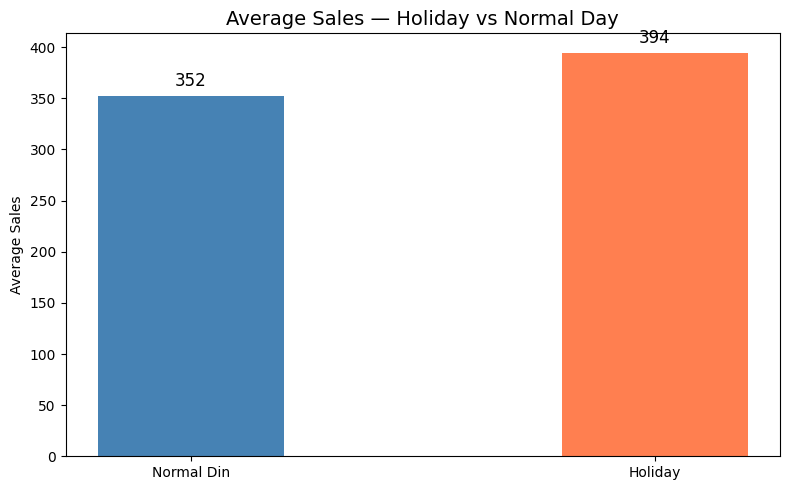


Holiday avg sales:    393.86
Normal day avg sales: 352.16


In [11]:

train_with_holidays = train.merge(holidays, on='date', how='left')
train_with_holidays['is_holiday'] = train_with_holidays['type'].notna().astype(int)


holiday_comparison = train_with_holidays.groupby('is_holiday')['sales'].mean().reset_index()
holiday_comparison['label'] = holiday_comparison['is_holiday'].map({0: 'Normal Din', 1: 'Holiday'})

plt.figure(figsize=(8, 5))
bars = plt.bar(holiday_comparison['label'], 
               holiday_comparison['sales'], 
               color=['steelblue', 'coral'], 
               width=0.4)


for bar, val in zip(bars, holiday_comparison['sales']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 10, 
             f'{val:.0f}', 
             ha='center', fontsize=12)

plt.title('Average Sales — Holiday vs Normal Day', fontsize=14)
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

print("\nHoliday avg sales:   ", round(holiday_comparison[holiday_comparison['is_holiday']==1]['sales'].values[0], 2))
print("Normal day avg sales:", round(holiday_comparison[holiday_comparison['is_holiday']==0]['sales'].values[0], 2))

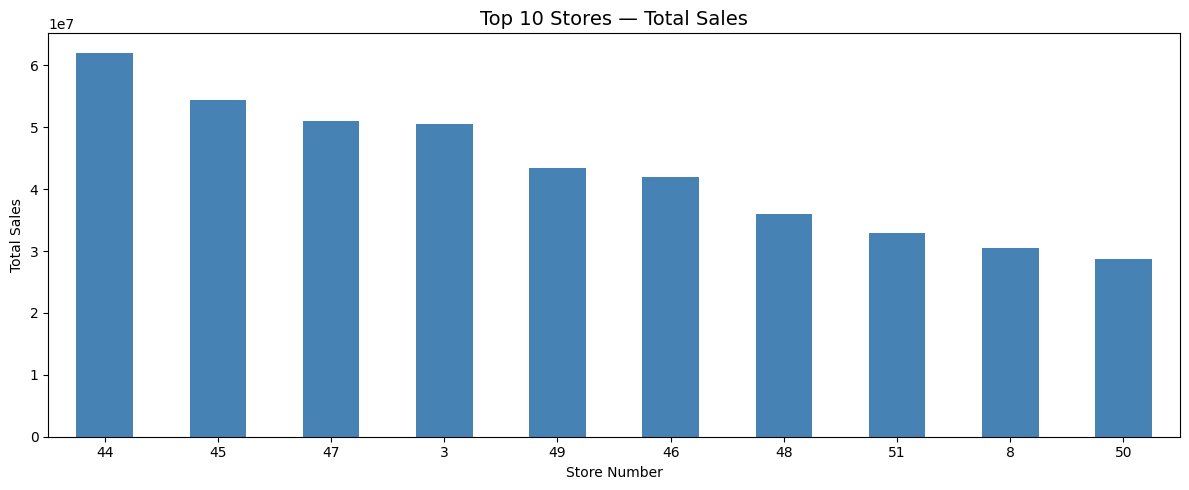

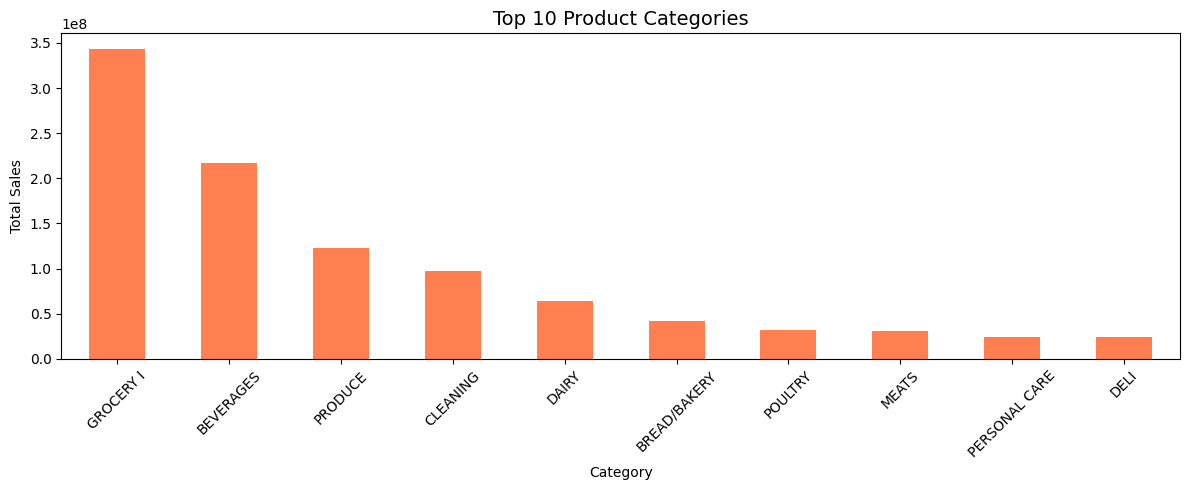

In [12]:

store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
store_sales.plot(kind='bar', color='steelblue')
plt.title('Top 10 Stores — Total Sales', fontsize=14)
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
family_sales.plot(kind='bar', color='coral')
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()